# SVD State Size Analysis

This notebook estimates how much storage a truncated SVD representation `(U, S, V)` would need for live Mamba cache state tensors, compared with the original dense tensors.

It mirrors the experiment setup at a high level:
- load a Mamba backend using the same helpers as the experiment script
- capture cache/state tensors after prefill and a small number of decode steps
- estimate `original_bytes` vs `compressed_bytes`
- summarize compression ratio by layer and state type (`conv` vs `recurrent`)

The notebook supports both:
- Hugging Face backend (`BACKEND_NAME = "hf"`)
- native `mamba_ssm` backend (`BACKEND_NAME = "mamba_ssm"`), including Mamba-2 style runs when your local install/model supports them

The notebook is parameterized so you can keep the scope small and adjust backend, model, rank, prompt, and number of analyzed steps.

In [9]:
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from state_spectrum_sweep.run_experiment_mamba import DTYPE, create_backend, extract_cache_tensors


In [14]:
# Configuration
BACKEND_NAME = "mamba_ssm"  # one of: hf, mamba_ssm

# Examples:
# BACKEND_NAME = "hf"; MODEL_NAME = "state-spaces/mamba-130m"; TOKENIZER_NAME = ""
# BACKEND_NAME = "mamba_ssm"; MODEL_NAME = "state-spaces/mamba-130m"; TOKENIZER_NAME = ""
# BACKEND_NAME = "mamba_ssm"; MODEL_NAME = "state-spaces/mamba2-130m"; TOKENIZER_NAME = ""
MODEL_NAME = "state-spaces/mamba2-2.7b"
TOKENIZER_NAME = ""
PROMPT = "Explain photosynthesis in one paragraph."
SUBSET = "auto"          # one of: auto, all, ssm, conv
LOW_RANK_RANK = 16
NUM_DECODE_STEPS = 4      # keep this small to make analysis light
FACTOR_STORAGE = "float32"  # one of: float32, state_dtype

assert BACKEND_NAME in {"hf", "mamba_ssm"}
assert FACTOR_STORAGE in {"float32", "state_dtype"}
print({
    "backend": BACKEND_NAME,
    "dtype": str(DTYPE),
    "rank": LOW_RANK_RANK,
    "decode_steps": NUM_DECODE_STEPS,
    "subset": SUBSET,
    "factor_storage": FACTOR_STORAGE,
    "model": MODEL_NAME,
})

{'backend': 'mamba_ssm', 'dtype': 'torch.bfloat16', 'rank': 16, 'decode_steps': 4, 'subset': 'auto', 'factor_storage': 'float32', 'model': 'state-spaces/mamba2-2.7b'}


In [15]:
backend = create_backend(
    backend_name=BACKEND_NAME,
    model_name=MODEL_NAME,
    tokenizer_name=TOKENIZER_NAME,
    dtype=DTYPE,
)

print(type(backend).__name__)
print("backend.device:", backend.device)
print("model type:", type(backend.model).__name__)
print("tokenizer:", type(backend.tokenizer).__name__)


NativeMambaBackend
backend.device: cuda
model type: MambaLMHeadModel
tokenizer: GPTNeoXTokenizer


In [25]:
def parse_state_name(name: str):
    lowered = name.lower()

    layer = -1
    state_kind = "other"

    m = re.search(r"key_value_memory_dict\.(\d+)\.(\d+)", lowered)
    if m:
        layer = int(m.group(1))
        slot = int(m.group(2))
        state_kind = f"slot_{slot}"
        return layer, state_kind

    patterns = [
        r"layers\.(\d+)",
        r"layer\.(\d+)",
        r"layer_(\d+)",
        r"blocks\.(\d+)",
        r"backbone\.layers\.(\d+)",
    ]
    for pattern in patterns:
        match = re.search(pattern, lowered)
        if match:
            layer = int(match.group(1))
            break

    if "conv" in lowered:
        state_kind = "conv"
    elif "recurrent" in lowered or "ssm" in lowered or "state" in lowered:
        state_kind = "recurrent"

    return layer, state_kind


def factor_element_size_bytes(tensor: torch.Tensor) -> int:
    if FACTOR_STORAGE == "state_dtype":
        return tensor.element_size()
    return torch.tensor([], dtype=torch.float32).element_size()


def svd_size_stats(tensor: torch.Tensor, rank: int):
    shape = tuple(int(x) for x in tensor.shape)
    original_numel = int(tensor.numel())
    original_bytes = original_numel * tensor.element_size()

    if tensor.ndim < 2:
        return {
            "original_shape": shape,
            "u_shape": None,
            "s_shape": None,
            "v_shape": None,
            "rank_used": None,
            "original_numel": original_numel,
            "original_bytes": original_bytes,
            "u_numel": 0,
            "s_numel": 0,
            "v_numel": 0,
            "compressed_numel": original_numel,
            "compressed_bytes": original_bytes,
            "compression_ratio": 1.0,
            "savings_bytes": 0,
            "supports_svd": False,
        }

    prefix = int(np.prod(shape[:-2])) if tensor.ndim > 2 else 1
    m, n = shape[-2], shape[-1]
    rank_used = max(1, min(rank, m, n))
    leading_shape = shape[:-2]
    u_shape = leading_shape + (m, rank_used)
    s_shape = leading_shape + (rank_used,)
    v_shape = leading_shape + (n, rank_used)

    u_numel = prefix * m * rank_used
    s_numel = prefix * rank_used
    v_numel = prefix * n * rank_used
    compressed_numel = u_numel + s_numel + v_numel
    compressed_bytes = compressed_numel * factor_element_size_bytes(tensor)

    compression_ratio = compressed_bytes / original_bytes if original_bytes else float("nan")

    return {
        "original_shape": shape,
        "u_shape": u_shape,
        "s_shape": s_shape,
        "v_shape": v_shape,
        "rank_used": rank_used,
        "original_numel": original_numel,
        "original_bytes": original_bytes,
        "u_numel": u_numel,
        "s_numel": s_numel,
        "v_numel": v_numel,
        "compressed_numel": compressed_numel,
        "compressed_bytes": compressed_bytes,
        "compression_ratio": compression_ratio,
        "savings_bytes": original_bytes - compressed_bytes,
        "supports_svd": True,
    }


def human_bytes(n: float) -> str:
    units = ["B", "KB", "MB", "GB", "TB"]
    value = float(n)
    for unit in units:
        if abs(value) < 1024.0 or unit == units[-1]:
            return f"{value:,.2f} {unit}"
        value /= 1024.0


In [26]:
input_ids = backend.prepare_prompt(PROMPT)

rows = []

with torch.inference_mode():
    logits, cache_obj = backend.prefill(input_ids, max_new_tokens=NUM_DECODE_STEPS)
    next_token = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)

    for step in range(NUM_DECODE_STEPS + 1):
        views = extract_cache_tensors(cache_obj, subset=SUBSET)
        for view in views:
            layer, state_kind = parse_state_name(view.path.name)
            stats = svd_size_stats(view.tensor, rank=LOW_RANK_RANK)
            rows.append({
                "step": step,
                "state_name": view.path.name,
                "layer": layer,
                "state_kind": state_kind,
                "dtype": str(view.tensor.dtype).replace("torch.", ""),
                **stats,
            })

        if step == NUM_DECODE_STEPS:
            break

        logits, cache_obj = backend.step(next_token, cache_obj)
        next_token = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)

df = pd.DataFrame(rows)
df["compression_percent"] = 100.0 * (1.0 - df["compression_ratio"])
df["original_human"] = df["original_bytes"].map(human_bytes)
df["compressed_human"] = df["compressed_bytes"].map(human_bytes)
df["savings_human"] = df["savings_bytes"].map(human_bytes)

print(f"captured {len(df)} tensor snapshots across {df['step'].nunique()} analysis steps")
df.head()

captured 640 tensor snapshots across 5 analysis steps


,step,state_name,layer,state_kind,dtype,original_shape,u_shape,s_shape,v_shape,rank_used,...,v_numel,compressed_numel,compressed_bytes,compression_ratio,savings_bytes,supports_svd,compression_percent,original_human,compressed_human,savings_human
0,0,key_value_memory_dict.0.0,0,slot_0,bfloat16,"(1, 5376, 4)","(1, 5376, 4)","(1, 4)","(1, 4, 4)",4,...,16,21524,86096,2.001860,-43088,True,-100.186012,42.00 KB,84.08 KB,-42.08 KB
1,0,key_value_memory_dict.0.1,0,slot_1,bfloat16,"(1, 80, 64, 128)","(1, 80, 64, 16)","(1, 80, 16)","(1, 80, 128, 16)",16,...,163840,247040,988160,0.753906,322560,True,24.609375,1.25 MB,965.00 KB,315.00 KB
2,0,key_value_memory_dict.1.0,1,slot_0,bfloat16,"(1, 5376, 4)","(1, 5376, 4)","(1, 4)","(1, 4, 4)",4,...,16,21524,86096,2.001860,-43088,True,-100.186012,42.00 KB,84.08 KB,-42.08 KB
3,0,key_value_memory_dict.1.1,1,slot_1,bfloat16,"(1, 80, 64, 128)","(1, 80, 64, 16)","(1, 80, 16)","(1, 80, 128, 16)",16,...,163840,247040,988160,0.753906,322560,True,24.609375,1.25 MB,965.00 KB,315.00 KB
4,0,key_value_memory_dict.2.0,2,slot_0,bfloat16,"(1, 5376, 4)","(1, 5376, 4)","(1, 4)","(1, 4, 4)",4,...,16,21524,86096,2.001860,-43088,True,-100.186012,42.00 KB,84.08 KB,-42.08 KB


In [27]:
overview = {
    "prompt": PROMPT,
    "steps_analyzed": int(df["step"].nunique()),
    "unique_state_tensors": int(df["state_name"].nunique()),
    "total_original_bytes": int(df["original_bytes"].sum()),
    "total_compressed_bytes": int(df["compressed_bytes"].sum()),
}
overview["total_savings_bytes"] = overview["total_original_bytes"] - overview["total_compressed_bytes"]
overview["overall_compression_ratio"] = overview["total_compressed_bytes"] / overview["total_original_bytes"]
overview["overall_compression_percent"] = 100.0 * (1.0 - overview["overall_compression_ratio"])

pd.Series({
    **overview,
    "total_original": human_bytes(overview["total_original_bytes"]),
    "total_compressed": human_bytes(overview["total_compressed_bytes"]),
    "total_savings": human_bytes(overview["total_savings_bytes"]),
})

prompt                         Explain photosynthesis in one paragraph.
steps_analyzed                                                        5
unique_state_tensors                                                128
total_original_bytes                                          433192960
total_compressed_bytes                                        343761920
total_savings_bytes                                            89431040
overall_compression_ratio                                      0.793554
overall_compression_percent                                    20.64462
total_original                                                413.12 MB
total_compressed                                              327.84 MB
total_savings                                                  85.29 MB
dtype: object

In [28]:
summary_by_kind = (
    df.groupby("state_kind", dropna=False)
    .agg(
        tensors=("state_name", "nunique"),
        snapshots=("state_name", "size"),
        original_bytes=("original_bytes", "sum"),
        compressed_bytes=("compressed_bytes", "sum"),
        avg_ratio=("compression_ratio", "mean"),
        median_ratio=("compression_ratio", "median"),
    )
    .reset_index()
)
summary_by_kind["savings_bytes"] = summary_by_kind["original_bytes"] - summary_by_kind["compressed_bytes"]
summary_by_kind["compression_percent"] = 100.0 * (1.0 - summary_by_kind["avg_ratio"])
summary_by_kind

,state_kind,tensors,snapshots,original_bytes,compressed_bytes,avg_ratio,median_ratio,savings_bytes,compression_percent
0,slot_0,64,320,13762560,27550720,2.001860,2.001860,-13788160,-100.186012
1,slot_1,64,320,419430400,316211200,0.753906,0.753906,103219200,24.609375


In [29]:
summary_by_layer = (
    df[df["layer"] >= 0]
    .groupby(["layer", "state_kind"], dropna=False)
    .agg(
        original_bytes=("original_bytes", "mean"),
        compressed_bytes=("compressed_bytes", "mean"),
        avg_ratio=("compression_ratio", "mean"),
        avg_percent=("compression_percent", "mean"),
    )
    .reset_index()
)
summary_by_layer.head(12)

,layer,state_kind,original_bytes,compressed_bytes,avg_ratio,avg_percent
0,0,slot_0,43008.0,86096.0,2.001860,-100.186012
1,0,slot_1,1310720.0,988160.0,0.753906,24.609375
2,1,slot_0,43008.0,86096.0,2.001860,-100.186012
3,1,slot_1,1310720.0,988160.0,0.753906,24.609375
4,2,slot_0,43008.0,86096.0,2.001860,-100.186012
5,2,slot_1,1310720.0,988160.0,0.753906,24.609375
6,3,slot_0,43008.0,86096.0,2.001860,-100.186012
7,3,slot_1,1310720.0,988160.0,0.753906,24.609375
8,4,slot_0,43008.0,86096.0,2.001860,-100.186012
9,4,slot_1,1310720.0,988160.0,0.753906,24.609375


In [30]:
largest_tensors = (
    df.sort_values(["original_bytes", "compression_ratio"], ascending=[False, True])
    [[
        "step", "state_name", "original_shape", "u_shape", "s_shape", "v_shape", "dtype", "rank_used",
        "original_human", "compressed_human", "savings_human", "compression_ratio", "compression_percent"
    ]]
    .head(20)
)
largest_tensors

,step,state_name,original_shape,u_shape,s_shape,v_shape,dtype,rank_used,original_human,compressed_human,savings_human,compression_ratio,compression_percent
1,0,key_value_memory_dict.0.1,"(1, 80, 64, 128)","(1, 80, 64, 16)","(1, 80, 16)","(1, 80, 128, 16)",bfloat16,16,1.25 MB,965.00 KB,315.00 KB,0.753906,24.609375
3,0,key_value_memory_dict.1.1,"(1, 80, 64, 128)","(1, 80, 64, 16)","(1, 80, 16)","(1, 80, 128, 16)",bfloat16,16,1.25 MB,965.00 KB,315.00 KB,0.753906,24.609375
5,0,key_value_memory_dict.2.1,"(1, 80, 64, 128)","(1, 80, 64, 16)","(1, 80, 16)","(1, 80, 128, 16)",bfloat16,16,1.25 MB,965.00 KB,315.00 KB,0.753906,24.609375
7,0,key_value_memory_dict.3.1,"(1, 80, 64, 128)","(1, 80, 64, 16)","(1, 80, 16)","(1, 80, 128, 16)",bfloat16,16,1.25 MB,965.00 KB,315.00 KB,0.753906,24.609375
9,0,key_value_memory_dict.4.1,"(1, 80, 64, 128)","(1, 80, 64, 16)","(1, 80, 16)","(1, 80, 128, 16)",bfloat16,16,1.25 MB,965.00 KB,315.00 KB,0.753906,24.609375
11,0,key_value_memory_dict.5.1,"(1, 80, 64, 128)","(1, 80, 64, 16)","(1, 80, 16)","(1, 80, 128, 16)",bfloat16,16,1.25 MB,965.00 KB,315.00 KB,0.753906,24.609375
13,0,key_value_memory_dict.6.1,"(1, 80, 64, 128)","(1, 80, 64, 16)","(1, 80, 16)","(1, 80, 128, 16)",bfloat16,16,1.25 MB,965.00 KB,315.00 KB,0.753906,24.609375
15,0,key_value_memory_dict.7.1,"(1, 80, 64, 128)","(1, 80, 64, 16)","(1, 80, 16)","(1, 80, 128, 16)",bfloat16,16,1.25 MB,965.00 KB,315.00 KB,0.753906,24.609375
17,0,key_value_memory_dict.8.1,"(1, 80, 64, 128)","(1, 80, 64, 16)","(1, 80, 16)","(1, 80, 128, 16)",bfloat16,16,1.25 MB,965.00 KB,315.00 KB,0.753906,24.609375
19,0,key_value_memory_dict.9.1,"(1, 80, 64, 128)","(1, 80, 64, 16)","(1, 80, 16)","(1, 80, 128, 16)",bfloat16,16,1.25 MB,965.00 KB,315.00 KB,0.753906,24.609375


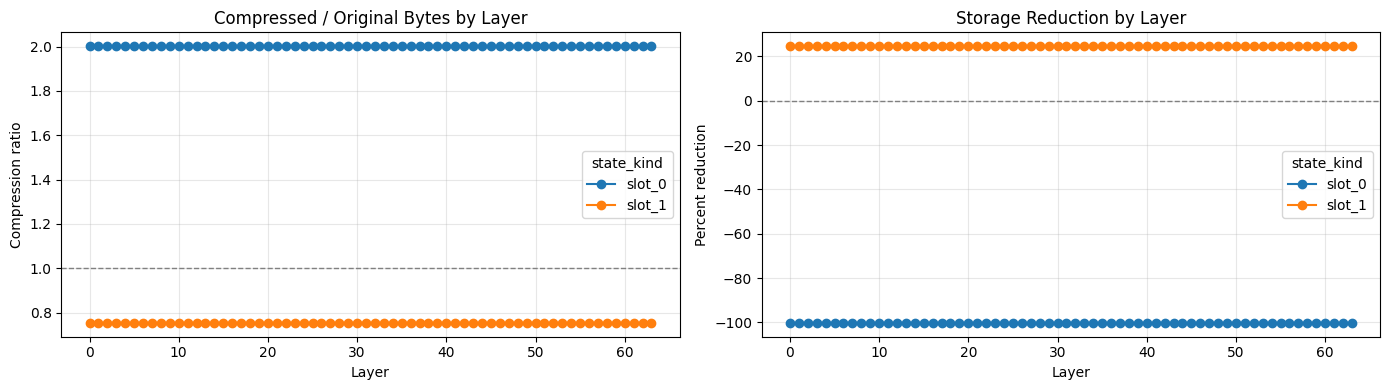

In [31]:
pivot_ratio = summary_by_layer.pivot(index="layer", columns="state_kind", values="avg_ratio")
pivot_percent = summary_by_layer.pivot(index="layer", columns="state_kind", values="avg_percent")

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

pivot_ratio.plot(ax=axes[0], marker="o")
axes[0].axhline(1.0, linestyle="--", color="gray", linewidth=1)
axes[0].set_title("Compressed / Original Bytes by Layer")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Compression ratio")
axes[0].grid(alpha=0.3)

pivot_percent.plot(ax=axes[1], marker="o")
axes[1].axhline(0.0, linestyle="--", color="gray", linewidth=1)
axes[1].set_title("Storage Reduction by Layer")
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Percent reduction")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
step_summary = (
    df.groupby("step")
    .agg(
        original_bytes=("original_bytes", "sum"),
        compressed_bytes=("compressed_bytes", "sum"),
        avg_ratio=("compression_ratio", "mean"),
    )
    .reset_index()
)
step_summary["compression_percent"] = 100.0 * (1.0 - step_summary["avg_ratio"])
step_summary

,step,original_bytes,compressed_bytes,avg_ratio,compression_percent
0,0,86638592,68752384,1.377883,-37.788318
1,1,86638592,68752384,1.377883,-37.788318
2,2,86638592,68752384,1.377883,-37.788318
3,3,86638592,68752384,1.377883,-37.788318
4,4,86638592,68752384,1.377883,-37.788318


## Notes

- This notebook estimates storage from tensor shapes and rank, rather than saving actual `U`, `S`, and `V` tensors to disk.
- It uses the same backend abstraction as `run_experiment_mamba.py`, so the capture path is close to the experiment path for both HF and native backends.
- For tensors with rank less than 2, it treats SVD compression as unsupported and leaves the storage unchanged.
- `FACTOR_STORAGE = "float32"` is the conservative setting, since SVD factors are often maintained in fp32 for stability.
- If you want a more optimistic estimate, switch to `FACTOR_STORAGE = "state_dtype"`.
- For native Mamba-2 runs, set `BACKEND_NAME = "mamba_ssm"` and point `MODEL_NAME` at the native checkpoint name you use in experiments.
- If you want to compare several prompts, wrap the capture loop over a prompt list and add a `prompt_id` column before concatenating rows.